# Imports

In [2]:
import numpy as np
import pandas as pd

import sklearn as sk
from sklearn import base
from sklearn import calibration
from sklearn import cluster
from sklearn import compose
from sklearn import covariance
from sklearn import cross_decomposition
from sklearn import datasets
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn import dummy
from sklearn import ensemble
from sklearn import exceptions
from sklearn import experimental
from sklearn import feature_extraction
from sklearn import feature_selection
from sklearn import gaussian_process
from sklearn import impute
from sklearn import inspection
from sklearn import isotonic
from sklearn import kernel_approximation
from sklearn import kernel_ridge
from sklearn import linear_model
from sklearn import manifold
from sklearn import metrics
from sklearn import mixture
from sklearn import model_selection
from sklearn import multiclass
from sklearn import multioutput
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import neural_network
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import random_projection
from sklearn import semi_supervised
from sklearn import svm
from sklearn import tree
from sklearn import utils

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analisi

## Es. 1

In [3]:
df = pd.read_csv('dataset.csv', sep=',')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
print('Rows (instances):', df.shape[0])
df.isnull().sum()

Rows (instances): 545


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Dataset completo.

## Es. 2

In [9]:
df.sort_values('price', ascending=False)['mainroad'].head(10)

0    yes
2    yes
1    yes
3    yes
4    yes
5    yes
6    yes
7    yes
8    yes
9    yes
Name: mainroad, dtype: object

In [10]:
df['mainroad'].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [11]:
df_mainroads = df[df['mainroad'] == 'yes'].copy()
df_mainroads

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished


In [13]:
pt = df_mainroads.pivot_table(values='price', index='guestroom', columns='basement', aggfunc='mean')
pt

basement,no,yes
guestroom,,
no,4.625947e+06,5.151417e+06
yes,6.277104e+06,5.807508e+06


In [14]:
guestroom_diff = pt.loc['yes', 'no'] - pt.loc['no', 'no']
basement_diff = pt.loc['no', 'yes'] - pt.loc['no', 'no']
guestroom_diff, basement_diff

(np.float64(1651157.4637681162), np.float64(525469.9637681162))

## Es. 3

<Axes: ylabel='Frequency'>

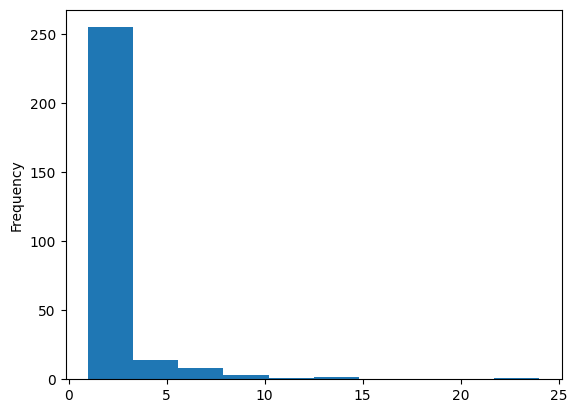

In [15]:
df['area'].value_counts().plot(kind='hist')

area_cut
gruppo2    232
gruppo1    164
gruppo3    124
gruppo4     21
gruppo5      4
Name: count, dtype: int64


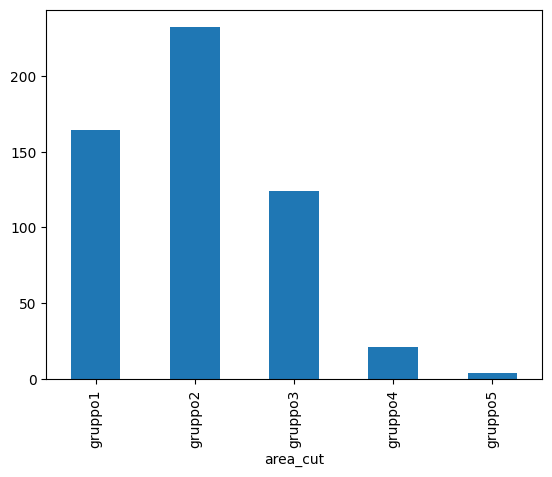

In [20]:
bins = [1649, 3660, 6150, 9150, 13150, 16200]
labels = ['gruppo1', 'gruppo2', 'gruppo3', 'gruppo4', 'gruppo5']

df['area_cut'] = pd.cut(df['area'], bins, labels=labels)

df["area_cut"].value_counts().sort_index().plot(kind="bar")
print(df["area_cut"].value_counts())

In [21]:
pd.crosstab(df['area_cut'], df['bedrooms'])

bedrooms,1,2,3,4,5,6
area_cut,,,,,,
gruppo1,1,55,84,20,3,1
gruppo2,1,59,125,43,3,1
gruppo3,0,16,78,27,3,0
gruppo4,0,5,11,5,0,0
gruppo5,0,1,2,0,1,0


## Es. 4

In [25]:
filtered_df = df[(df['bathrooms'] >= 2) & (df['bedrooms'] >= 2)].copy()
filtered_df['airconditioning'] = filtered_df['airconditioning'].map({'yes': 1, 'no': 0})
filtered_df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_cut
0,13300000,7420,4,2,3,yes,no,no,no,1,2,yes,furnished,gruppo3
1,12250000,8960,4,4,4,yes,no,no,no,1,3,no,furnished,gruppo3
2,12250000,9960,3,2,2,yes,no,yes,no,0,2,yes,semi-furnished,gruppo4
3,12215000,7500,4,2,2,yes,no,yes,no,1,3,yes,furnished,gruppo3
5,10850000,7500,3,3,1,yes,no,yes,no,1,2,yes,semi-furnished,gruppo3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3430000,1950,3,2,2,yes,no,yes,no,0,0,yes,unfurnished,gruppo1
446,3150000,3986,2,2,1,no,yes,yes,no,0,1,no,unfurnished,gruppo2
499,2660000,3630,3,3,2,no,yes,no,no,0,0,no,unfurnished,gruppo1
509,2590000,3600,2,2,2,yes,no,yes,no,0,1,no,furnished,gruppo1


Text(0, 0.5, 'area')

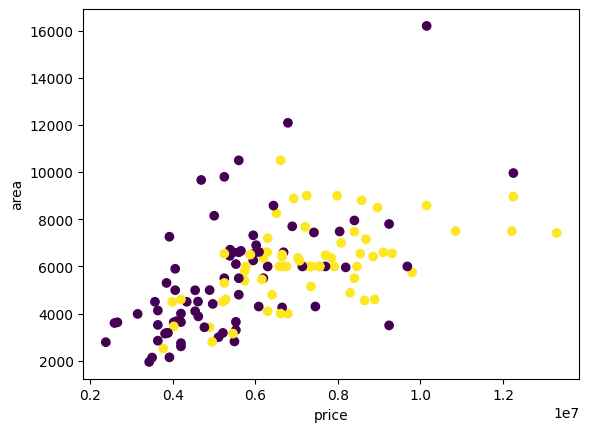

In [30]:
plt.scatter(filtered_df['price'], filtered_df['area'], c=filtered_df['airconditioning'])
plt.xlabel('price')
plt.ylabel('area')